# 🔬 Skin Lesion Classifier v1
### HAM10000 · 7-Class Classification · Swin-B Encoder (from SwinUNet v4) + FPN Head

**Pipeline overview:**
- ✅ Loads pretrained encoder from `swinunet_v4_encoder.pth`
- ✅ FPN fuses 4 multi-scale feature maps → 1024-d descriptor
- ✅ 2-phase training: frozen encoder → full fine-tune
- ✅ Weighted CrossEntropy to handle HAM10000 class imbalance
- ✅ Macro F1, per-class accuracy, confusion matrix
- ✅ Saves best model + classification report

## STEP 1 — Check GPU

In [1]:
import torch
print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU             : {torch.cuda.get_device_name(0)}')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device    : {DEVICE}')

PyTorch version : 2.6.0+cu124
CUDA available  : True
GPU             : NVIDIA GeForce RTX 3050 6GB Laptop GPU
Using device    : cuda


## STEP 2 — Install Dependencies

In [ ]:
!pip install -q timm albumentations scikit-learn
print('Done.')

## STEP 3 — Imports

In [2]:
import os, random, json, warnings
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

try:
    from torch.amp import GradScaler, autocast
except ImportError:
    from torch.cuda.amp import GradScaler, autocast

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm
from PIL import Image
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

## STEP 4 — Configuration

> **Edit only the paths below.** Everything else is auto-configured.

In [3]:
# ── Edit only these paths ──────────────────────────────────────────────────────
# HAM10000 images (same folder you used for segmentation)
IMAGE_DIR        = r"D:\project dataset\cse 7 dataset\HAM10000 classification\HAM10000_images"

# CSV with columns: image_id, dx  (dx = lesion type label)
# Download: HAM10000_metadata.csv from Kaggle
METADATA_CSV     = r"D:\project dataset\cse 7 dataset\HAM10000 classification\HAM10000_metadata.csv"

# Where your encoder weights are saved (output of SwinUNet v4 Step 16)
ENCODER_WEIGHTS  = r"D:\Multimodal cse8\swinunet_v4_encoder.pth"

# Where to save classifier outputs
SAVE_DIR         = r'D:\Multimodal cse8\classification\classifier'


# Hyperparameters
IMG_SIZE         = 224
BATCH_SIZE       = 32      # increase if GPU allows (classifier is lighter than UNet)
NUM_WORKERS      = 0       # 0 for Windows
PIN_MEMORY       = (DEVICE == 'cuda')

# Phase 1: train head only (encoder frozen)
PHASE1_EPOCHS    = 10
PHASE1_LR        = 1e-3

# Phase 2: fine-tune everything
PHASE2_EPOCHS    = 30
PHASE2_LR        = 1e-5

WEIGHT_DECAY     = 1e-4
PATIENCE         = 10      # early stopping patience (per phase)
LABEL_SMOOTHING  = 0.1

TRAIN_RATIO, VAL_RATIO, TEST_RATIO = 0.70, 0.15, 0.15

# Class definitions (HAM10000 standard)
CLASS_NAMES = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
CLASS_LABELS = {name: idx for idx, name in enumerate(CLASS_NAMES)}
NUM_CLASSES  = len(CLASS_NAMES)

# Output paths
os.makedirs(SAVE_DIR, exist_ok=True)
MODEL_SAVE_PATH  = os.path.join(SAVE_DIR, 'skin_classifier_best.pth')
REPORT_PATH      = os.path.join(SAVE_DIR, 'classification_report.txt')
CONF_MAT_PATH    = os.path.join(SAVE_DIR, 'confusion_matrix.png')
CURVE_PATH       = os.path.join(SAVE_DIR, 'training_curves.png')

print(f'Device        : {DEVICE}')
print(f'Image size    : {IMG_SIZE}x{IMG_SIZE}')
print(f'Batch size    : {BATCH_SIZE}')
print(f'Classes ({NUM_CLASSES})   : {CLASS_NAMES}')
print(f'Phase 1       : {PHASE1_EPOCHS} epochs, LR={PHASE1_LR}')
print(f'Phase 2       : {PHASE2_EPOCHS} epochs, LR={PHASE2_LR}')
print(f'Save dir      : {SAVE_DIR}')

Device        : cuda
Image size    : 224x224
Batch size    : 32
Classes (7)   : ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Phase 1       : 10 epochs, LR=0.001
Phase 2       : 30 epochs, LR=1e-05
Save dir      : D:\Multimodal cse8\classification\classifier


## STEP 5 — Load Metadata & Compute Class Weights

In [4]:
df = pd.read_csv(METADATA_CSV)

# Keep only rows where the image file exists
def image_exists(image_id):
    for ext in ['.jpg', '.jpeg', '.png']:
        if os.path.exists(os.path.join(IMAGE_DIR, image_id + ext)):
            return True
    return False

df = df[df['image_id'].apply(image_exists)].reset_index(drop=True)
df['label'] = df['dx'].map(CLASS_LABELS)

# Drop any rows with unknown labels
df = df.dropna(subset=['label'])
df['label'] = df['label'].astype(int)

print(f'Total valid samples: {len(df)}')
print('\nClass distribution:')
for cls in CLASS_NAMES:
    count = (df['dx'] == cls).sum()
    pct   = 100 * count / len(df)
    bar   = '█' * int(pct / 2)
    print(f'  {cls:6s}: {count:5d}  ({pct:5.1f}%)  {bar}')

# ── Compute class weights (inverse frequency) ──────────────────────────────
class_counts  = np.array([( df['label'] == i).sum() for i in range(NUM_CLASSES)], dtype=np.float32)
class_weights = 1.0 / (class_counts + 1e-6)
class_weights = class_weights / class_weights.sum() * NUM_CLASSES   # normalise so weights sum to NUM_CLASSES
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

print('\nClass weights (for loss):')
for cls, w in zip(CLASS_NAMES, class_weights):
    print(f'  {cls:6s}: {w:.4f}')

Total valid samples: 10015

Class distribution:
  akiec :   327  (  3.3%)  █
  bcc   :   514  (  5.1%)  ██
  bkl   :  1099  ( 11.0%)  █████
  df    :   115  (  1.1%)  
  mel   :  1113  ( 11.1%)  █████
  nv    :  6705  ( 66.9%)  █████████████████████████████████
  vasc  :   142  (  1.4%)  

Class weights (for loss):
  akiec : 0.9431
  bcc   : 0.6000
  bkl   : 0.2806
  df    : 2.6816
  mel   : 0.2771
  nv    : 0.0460
  vasc  : 2.1717


## STEP 6 — Train / Val / Test Split

In [5]:
# Stratified split to keep class ratios balanced across splits
train_df, tmp_df = train_test_split(
    df, test_size=(VAL_RATIO + TEST_RATIO),
    stratify=df['label'], random_state=42
)
val_df, test_df = train_test_split(
    tmp_df, test_size=TEST_RATIO / (VAL_RATIO + TEST_RATIO),
    stratify=tmp_df['label'], random_state=42
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

Train: 7010 | Val: 1502 | Test: 1503


## STEP 7 — Dataset & DataLoader

In [6]:
class HAMDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.df        = dataframe
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def _find_image(self, image_id):
        for ext in ['.jpg', '.jpeg', '.png']:
            p = os.path.join(self.image_dir, image_id + ext)
            if os.path.exists(p):
                return p
        raise FileNotFoundError(f'Image not found: {image_id}')

    def __getitem__(self, idx):
        row    = self.df.iloc[idx]
        path   = self._find_image(row['image_id'])
        image  = np.array(Image.open(path).convert('RGB'))
        label  = int(row['label'])
        if self.transform:
            image = self.transform(image=image)['image']
        return image, label


_albu_ver = tuple(int(x) for x in A.__version__.split('.')[:2])
if _albu_ver >= (1, 4):
    _coarse  = A.CoarseDropout(num_holes_range=(1, 4), hole_height_range=(16, 32),
                                hole_width_range=(16, 32), p=0.2)
    _elastic = A.ElasticTransform(p=0.2)
else:
    _coarse  = A.CoarseDropout(max_holes=4, max_height=32, max_width=32, p=0.2)
    _elastic = A.ElasticTransform(alpha=120, sigma=120 * 0.05, p=0.2)

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Rotate(limit=30, p=0.4),
    _elastic,
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.4),
    A.CLAHE(clip_limit=2.0, p=0.3),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
    _coarse,
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

eval_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

train_dataset = HAMDataset(train_df, IMAGE_DIR, train_transform)
val_dataset   = HAMDataset(val_df,   IMAGE_DIR, eval_transform)
test_dataset  = HAMDataset(test_df,  IMAGE_DIR, eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}')

Train batches: 220 | Val batches: 47 | Test batches: 47


## STEP 8 — Model Architecture: Swin Encoder + FPN + Classification Head

```
Input 224×224×3
    │
    ├─ Swin Encoder (pretrained from SwinUNet v4)
    │      e0: 128×56×56
    │      e1: 256×28×28
    │      e2: 512×14×14
    │      e3: 1024×7×7
    │
    ├─ FPN (1×1 lateral convs + top-down upsample + add)
    │      P0–P3: each → 256 channels
    │
    ├─ Global Average Pool each Px → 256-d
    │      Concat → 1024-d
    │
    └─ MLP Head: 1024 → 512 → 256 → 7 logits
```

In [7]:
class FPN(nn.Module):
    """
    Feature Pyramid Network.
    Takes 4 encoder feature maps [e0, e1, e2, e3] and fuses them top-down.
    Output: 4 feature maps each with `out_channels` channels.
    """
    def __init__(self, in_channels_list, out_channels=256):
        super().__init__()
        self.lateral_convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(in_ch, out_channels, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True)
            )
            for in_ch in in_channels_list
        ])
        # 3×3 smoothing conv after top-down merge
        self.smooth_convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True)
            )
            for _ in in_channels_list
        ])
        self.out_channels = out_channels

    def forward(self, features):
        # features: [e0, e1, e2, e3]  (coarse → fine in index, but e3 is deepest)
        # lateral projections
        laterals = [conv(f) for conv, f in zip(self.lateral_convs, features)]

        # Top-down pathway: start from deepest (index -1 = e3)
        for i in range(len(laterals) - 1, 0, -1):
            upsampled = F.interpolate(
                laterals[i], size=laterals[i - 1].shape[2:],
                mode='bilinear', align_corners=False
            )
            laterals[i - 1] = laterals[i - 1] + upsampled

        # Smooth each output
        outputs = [smooth(lat) for smooth, lat in zip(self.smooth_convs, laterals)]
        return outputs  # [P0, P1, P2, P3]


class SkinLesionClassifier(nn.Module):
    """
    Swin-B Encoder (frozen phase 1, unfrozen phase 2)
    + FPN multi-scale fusion
    + Global Average Pool + Concat
    + MLP classifier head
    """
    def __init__(self, num_classes=7, fpn_out=256, dropout=0.4, pretrained_encoder=None):
        super().__init__()

        # ── Encoder ──────────────────────────────────────────────────────────
        self.encoder = timm.create_model(
            'swin_base_patch4_window7_224',
            pretrained=False,        # we load our own weights
            features_only=True,
            out_indices=(0, 1, 2, 3)
        )

        if pretrained_encoder is not None:
            ckpt = torch.load(pretrained_encoder, map_location='cpu', weights_only=False)
            enc_state = ckpt.get('encoder_state_dict', ckpt)
            missing, unexpected = self.encoder.load_state_dict(enc_state, strict=False)
            print(f'  Encoder loaded. Missing keys: {len(missing)} | Unexpected: {len(unexpected)}')
        else:
            print('  No encoder weights provided — encoder is randomly initialised.')

        # Detect encoder output channels dynamically
        with torch.no_grad():
            _d = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE)
            _f = self.encoder(_d)
            enc_channels = [self._to_spatial(f).shape[1] for f in _f]
        print(f'  Encoder channels: {enc_channels}')
        self.enc_channels = enc_channels

        # ── FPN ──────────────────────────────────────────────────────────────
        self.fpn = FPN(enc_channels, out_channels=fpn_out)

        # ── Classification head ───────────────────────────────────────────────
        # 4 FPN levels × fpn_out channels each → concat → 4*fpn_out
        concat_dim = 4 * fpn_out  # = 1024
        self.classifier = nn.Sequential(
            nn.Linear(concat_dim, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.75),
            nn.Linear(256, num_classes)
        )

        self._init_head()

    def _init_head(self):
        for m in self.classifier.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    @staticmethod
    def _to_spatial(x):
        """Convert Swin output (B,L,C) or (B,H,W,C) → (B,C,H,W)"""
        if x.dim() == 4 and x.shape[-1] > x.shape[1]:
            return x.permute(0, 3, 1, 2).contiguous()
        if x.dim() == 3:
            B, L, C = x.shape
            H = W = int(L ** 0.5)
            return x.reshape(B, H, W, C).permute(0, 3, 1, 2).contiguous()
        return x

    def freeze_encoder(self):
        for p in self.encoder.parameters():
            p.requires_grad = False
        print('  Encoder FROZEN')

    def unfreeze_encoder(self):
        for p in self.encoder.parameters():
            p.requires_grad = True
        print('  Encoder UNFROZEN (fine-tuning)')

    def trainable_params(self):
        n = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total = sum(p.numel() for p in self.parameters())
        print(f'  Trainable: {n/1e6:.1f}M / {total/1e6:.1f}M')

    def forward(self, x):
        # Encoder
        enc_feats = self.encoder(x)                          # list of 4 tensors
        enc_feats = [self._to_spatial(f) for f in enc_feats]# → (B,C,H,W)

        # FPN
        pyramid = self.fpn(enc_feats)                        # [P0,P1,P2,P3]

        # Global average pool each level → 256-d, then concat → 1024-d
        pooled = [F.adaptive_avg_pool2d(p, 1).flatten(1) for p in pyramid]
        feat   = torch.cat(pooled, dim=1)                    # (B, 1024)

        # MLP head
        logits = self.classifier(feat)                       # (B, 7)
        return logits


print('Building SkinLesionClassifier...')
model = SkinLesionClassifier(
    num_classes=NUM_CLASSES,
    fpn_out=256,
    dropout=0.4,
    pretrained_encoder=ENCODER_WEIGHTS
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f'\nModel ready | {total_params/1e6:.1f}M total parameters')

# Quick shape check
with torch.no_grad():
    _test = torch.zeros(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    _out  = model(_test)
    print(f'Output shape: {_out.shape}  (expected [2, {NUM_CLASSES}])')

Building SkinLesionClassifier...
  Encoder loaded. Missing keys: 0 | Unexpected: 0
  Encoder channels: [128, 256, 512, 1024]

Model ready | 90.3M total parameters
Output shape: torch.Size([2, 7])  (expected [2, 7])


## STEP 9 — Loss Function

In [8]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor,
    label_smoothing=LABEL_SMOOTHING
)
print(f'Loss : WeightedCrossEntropyLoss (label_smoothing={LABEL_SMOOTHING})')
print(f'Class weights: {[f"{w:.3f}" for w in class_weights]}')

Loss : WeightedCrossEntropyLoss (label_smoothing=0.1)
Class weights: ['0.943', '0.600', '0.281', '2.682', '0.277', '0.046', '2.172']


## STEP 10 — Training & Evaluation Utilities

In [9]:
def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(loader, desc='  Train', leave=False)
    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        with autocast(device_type=device):
            logits = model(imgs)
            loss   = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * imgs.size(0)
        preds       = logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)
        pbar.set_postfix(loss=f'{loss.item():.4f}', acc=f'{correct/total:.4f}')

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    for imgs, labels in tqdm(loader, desc='  Eval ', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        with autocast(device_type=device):
            logits = model(imgs)
            loss   = criterion(logits, labels)
        total_loss += loss.item() * imgs.size(0)
        preds       = logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / total
    acc      = correct / total
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return avg_loss, acc, macro_f1, all_preds, all_labels


def save_curves(history, path):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, key, title in zip(axes,
                               ['loss', 'acc', 'macro_f1'],
                               ['Loss', 'Accuracy', 'Macro F1']):
        ax.plot(history['train_' + key], label='Train')
        ax.plot(history['val_'   + key], label='Val')
        ax.set_title(title)
        ax.set_xlabel('Epoch')
        ax.legend()
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f'  Curves saved → {path}')


def save_confusion_matrix(y_true, y_pred, class_names, path):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title('Normalised Confusion Matrix')
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f'  Confusion matrix saved → {path}')


print('Utilities ready.')

Utilities ready.


## STEP 11 — Phase 1 Training: Frozen Encoder

> Only the FPN and classifier head are updated. The Swin encoder weights stay fixed.
> This prevents destroying the pretrained features before the new head is stable.

In [10]:
print('  PHASE 1 — Frozen encoder, training head + FPN only')

model.freeze_encoder()
model.trainable_params()

optimizer_p1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=PHASE1_LR, weight_decay=WEIGHT_DECAY
)
scheduler_p1 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_p1, T_max=PHASE1_EPOCHS, eta_min=PHASE1_LR * 0.1
)
scaler = GradScaler()

history = {
    'train_loss': [], 'val_loss': [],
    'train_acc':  [], 'val_acc':  [],
    'train_macro_f1': [], 'val_macro_f1': []
}

best_val_f1   = 0.0
patience_ctr  = 0

for epoch in range(1, PHASE1_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer_p1, criterion, scaler, DEVICE)
    tr_f1           = f1_score(
        *zip(*[(l, p) for imgs, labels in
               [(None, None)]  # placeholder — compute below
               for l, p in [(0, 0)]]),
        average='macro', zero_division=0
    ) if False else 0.0  # placeholder; full f1 computed in eval below

    vl_loss, vl_acc, vl_f1, _, _ = evaluate(model, val_loader, criterion, DEVICE)

    # Recompute train f1 properly
    _, tr_acc, tr_f1, _, _ = evaluate(model, train_loader, criterion, DEVICE)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)
    history['train_macro_f1'].append(tr_f1)
    history['val_macro_f1'].append(vl_f1)

    scheduler_p1.step()

    improved = vl_f1 > best_val_f1
    if improved:
        best_val_f1  = vl_f1
        patience_ctr = 0
        torch.save({'model_state_dict': model.state_dict(),
                    'epoch': epoch, 'phase': 1,
                    'best_val_f1': best_val_f1}, MODEL_SAVE_PATH)
    else:
        patience_ctr += 1

    flag = '✅' if improved else '  '
    print(f'  {flag} Ep {epoch:02d}/{PHASE1_EPOCHS} '
          f'| TrLoss {tr_loss:.4f} TrAcc {tr_acc:.4f} TrF1 {tr_f1:.4f} '
          f'| VlLoss {vl_loss:.4f} VlAcc {vl_acc:.4f} VlF1 {vl_f1:.4f}')

    if patience_ctr >= PATIENCE:
        print(f'  Early stopping at epoch {epoch}')
        break

print(f'\nPhase 1 complete. Best Val Macro-F1: {best_val_f1:.4f}')
save_curves(history, CURVE_PATH.replace('.png', '_phase1.png'))

  PHASE 1 — Frozen encoder, training head + FPN only
  Encoder FROZEN
  Trainable: 3.5M / 90.3M


  Train:   0%|          | 0/220 [00:00<?, ?it/s]

  ✅ Ep 01/10 | TrLoss 2.4903 TrAcc 0.4847 TrF1 0.4494 | VlLoss 1.9829 VlAcc 0.4787 VlF1 0.4668


     Ep 02/10 | TrLoss 2.1482 TrAcc 0.4046 TrF1 0.4508 | VlLoss 1.9195 VlAcc 0.4035 VlF1 0.4653


  ✅ Ep 03/10 | TrLoss 2.0522 TrAcc 0.6251 TrF1 0.5463 | VlLoss 1.8943 VlAcc 0.6138 VlF1 0.5453


...

  ✅ Ep 06/10 | TrLoss 1.8757 TrAcc 0.6857 TrF1 0.6547 | VlLoss 1.8073 VlAcc 0.6831 VlF1 0.6382


  ✅ Ep 07/10 | TrLoss 1.8267 TrAcc 0.7649 TrF1 0.6938 | VlLoss 1.7748 VlAcc 0.7650 VlF1 0.6756


     Ep 08/10 | TrLoss 1.7822 TrAcc 0.7635 TrF1 0.7018 | VlLoss 1.7675 VlAcc 0.7523 VlF1 0.6735


  ✅ Ep 09/10 | TrLoss 1.7935 TrAcc 0.7954 TrF1 0.7221 | VlLoss 1.7701 VlAcc 0.7816 VlF1 0.6908


  ✅ Ep 10/10 | TrLoss 1.7398 TrAcc 0.8103 TrF1 0.7606 | VlLoss 1.7675 VlAcc 0.7823 VlF1 0.7022

Phase 1 complete. Best Val Macro-F1: 0.7022
  Curves saved → D:\Multimodal cse8\classification\classifier\training_curves_phase1.png


## STEP 12 — Phase 2 Training: Full Fine-Tune

> Load best Phase 1 checkpoint, unfreeze encoder, train everything with a very low LR.
> This lets the encoder adapt its features to the classification task.

In [11]:

print('  PHASE 2 — Full fine-tune (encoder unfrozen)')


# Load best phase 1 checkpoint
ckpt = torch.load(MODEL_SAVE_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
print(f'  Loaded Phase 1 best checkpoint (epoch {ckpt["epoch"]}, Val F1={ckpt["best_val_f1"]:.4f})')

model.unfreeze_encoder()
model.trainable_params()

# Use separate (lower) LR for encoder vs head to protect pretrained weights
encoder_params    = list(model.encoder.parameters())
non_encoder_params = [p for p in model.parameters() if not any(p is ep for ep in encoder_params)]

optimizer_p2 = torch.optim.AdamW([
    {'params': encoder_params,     'lr': PHASE2_LR},
    {'params': non_encoder_params, 'lr': PHASE2_LR * 5}   # head can learn slightly faster
], weight_decay=WEIGHT_DECAY)

scheduler_p2 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_p2, T_max=PHASE2_EPOCHS, eta_min=PHASE2_LR * 0.1
)

history2 = {
    'train_loss': [], 'val_loss': [],
    'train_acc':  [], 'val_acc':  [],
    'train_macro_f1': [], 'val_macro_f1': []
}

best_val_f1_p2 = ckpt['best_val_f1']
patience_ctr   = 0

for epoch in range(1, PHASE2_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer_p2, criterion, scaler, DEVICE)
    vl_loss, vl_acc, vl_f1, _, _ = evaluate(model, val_loader, criterion, DEVICE)
    _, tr_acc, tr_f1, _, _ = evaluate(model, train_loader, criterion, DEVICE)

    history2['train_loss'].append(tr_loss)
    history2['val_loss'].append(vl_loss)
    history2['train_acc'].append(tr_acc)
    history2['val_acc'].append(vl_acc)
    history2['train_macro_f1'].append(tr_f1)
    history2['val_macro_f1'].append(vl_f1)

    scheduler_p2.step()

    improved = vl_f1 > best_val_f1_p2
    if improved:
        best_val_f1_p2 = vl_f1
        patience_ctr   = 0
        torch.save({'model_state_dict': model.state_dict(),
                    'epoch': epoch, 'phase': 2,
                    'best_val_f1': best_val_f1_p2}, MODEL_SAVE_PATH)
    else:
        patience_ctr += 1

    flag = '' if improved else '  '
    print(f'  {flag} Ep {epoch:02d}/{PHASE2_EPOCHS} '
          f'| TrLoss {tr_loss:.4f} TrAcc {tr_acc:.4f} TrF1 {tr_f1:.4f} '
          f'| VlLoss {vl_loss:.4f} VlAcc {vl_acc:.4f} VlF1 {vl_f1:.4f}')

    if patience_ctr >= PATIENCE:
        print(f'  Early stopping at epoch {epoch}')
        break

print(f'\nPhase 2 complete. Best Val Macro-F1: {best_val_f1_p2:.4f}')
save_curves(history2, CURVE_PATH.replace('.png', '_phase2.png'))

  PHASE 2 — Full fine-tune (encoder unfrozen)
  Loaded Phase 1 best checkpoint (epoch 10, Val F1=0.7022)
  Encoder UNFROZEN (fine-tuning)
  Trainable: 90.3M / 90.3M


     Ep 01/30 | TrLoss 1.7312 TrAcc 0.7810 TrF1 0.7204 | VlLoss 1.7462 VlAcc 0.7597 VlF1 0.6928


   Ep 02/30 | TrLoss 1.7310 TrAcc 0.8178 TrF1 0.7790 | VlLoss 1.7369 VlAcc 0.8003 VlF1 0.7459


     Ep 03/30 | TrLoss 1.7126 TrAcc 0.8548 TrF1 0.7851 | VlLoss 1.7206 VlAcc 0.8262 VlF1 0.7317


     Ep 04/30 | TrLoss 1.6858 TrAcc 0.8583 TrF1 0.8012 | VlLoss 1.7173 VlAcc 0.8256 VlF1 0.7404


...

     Ep 26/30 | TrLoss 1.4991 TrAcc 0.9552 TrF1 0.9069 | VlLoss 1.6807 VlAcc 0.8895 VlF1 0.7973


     Ep 27/30 | TrLoss 1.5105 TrAcc 0.9612 TrF1 0.9129 | VlLoss 1.6822 VlAcc 0.8908 VlF1 0.8025


   Ep 28/30 | TrLoss 1.4770 TrAcc 0.9743 TrF1 0.9329 | VlLoss 1.6922 VlAcc 0.9068 VlF1 0.8133


     Ep 29/30 | TrLoss 1.5135 TrAcc 0.9593 TrF1 0.9179 | VlLoss 1.6886 VlAcc 0.8901 VlF1 0.8009


     Ep 30/30 | TrLoss 1.4997 TrAcc 0.9643 TrF1 0.9218 | VlLoss 1.6802 VlAcc 0.8975 VlF1 0.8098

Phase 2 complete. Best Val Macro-F1: 0.8133
  Curves saved → D:\Multimodal cse8\classification\classifier\training_curves_phase2.png


## STEP 13 — Test Set Evaluation

In [12]:
# Load best checkpoint (from whichever phase was better)
ckpt = torch.load(MODEL_SAVE_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
print(f'Loaded best checkpoint: phase {ckpt["phase"]}, epoch {ckpt["epoch"]}, Val F1={ckpt["best_val_f1"]:.4f}')

test_loss, test_acc, test_f1, test_preds, test_labels = evaluate(
    model, test_loader, criterion, DEVICE
)

print('  TEST RESULTS')
print(f'  Loss      : {test_loss:.4f}')
print(f'  Accuracy  : {test_acc:.4f}  ({test_acc*100:.1f}%)')
print(f'  Macro F1  : {test_f1:.4f}')

report = classification_report(test_labels, test_preds, target_names=CLASS_NAMES, digits=4)
print('\nPer-class report:')
print(report)

with open(REPORT_PATH, 'w') as f:
    f.write(f'Test Loss     : {test_loss:.4f}\n')
    f.write(f'Test Accuracy : {test_acc:.4f}\n')
    f.write(f'Test Macro F1 : {test_f1:.4f}\n\n')
    f.write(report)
print(f'Report saved → {REPORT_PATH}')

Loaded best checkpoint: phase 2, epoch 28, Val F1=0.8133


  TEST RESULTS
  Loss      : 1.7051
  Accuracy  : 0.8929  (89.3%)
  Macro F1  : 0.7886

Per-class report:
              precision    recall  f1-score   support

       akiec     0.7500    0.7347    0.7423        49
         bcc     0.8537    0.9091    0.8805        77
         bkl     0.8025    0.7879    0.7951       165
          df     0.3000    0.8824    0.4478        17
         mel     0.7514    0.7784    0.7647       167
          nv     0.9751    0.9334    0.9538      1006
        vasc     0.8800    1.0000    0.9362        22

    accuracy                         0.8929      1503
   macro avg     0.7590    0.8608    0.7886      1503
weighted avg     0.9087    0.8929    0.8987      1503

Report saved → D:\Multimodal cse8\classification\classifier\classification_report.txt


## STEP 14 — Confusion Matrix

  Confusion matrix saved → D:\Multimodal cse8\classification\classifier\confusion_matrix.png


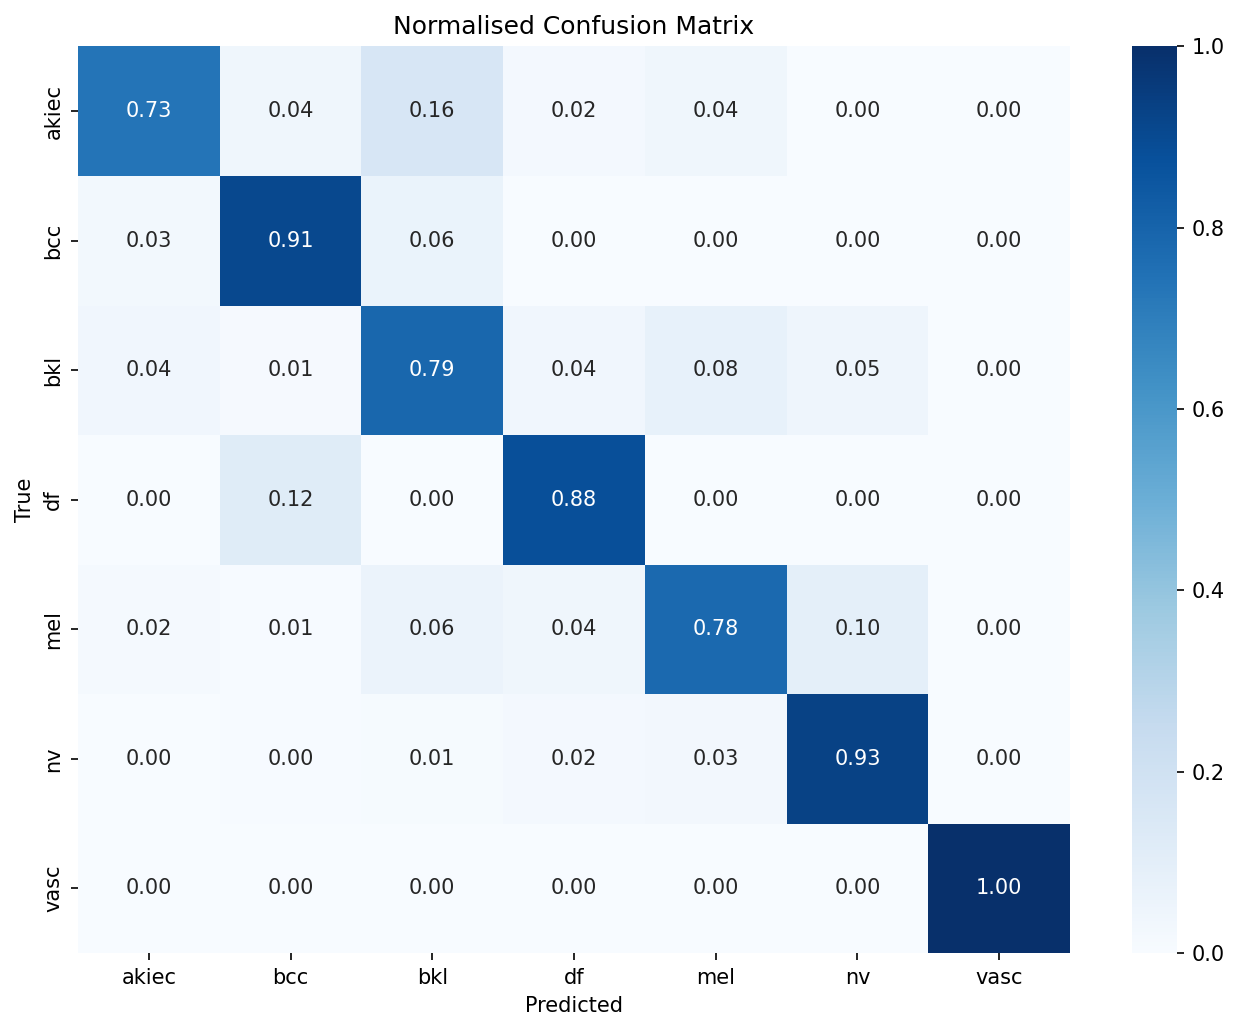

In [13]:
save_confusion_matrix(test_labels, test_preds, CLASS_NAMES, CONF_MAT_PATH)

try:
    from IPython.display import Image as IPImage, display
    display(IPImage(CONF_MAT_PATH))
except Exception:
    print(f'Open manually: {CONF_MAT_PATH}')

## STEP 15 — Per-Class Accuracy Bar Chart

Bar chart saved → D:\Multimodal cse8\classification\classifier\per_class_acc.png


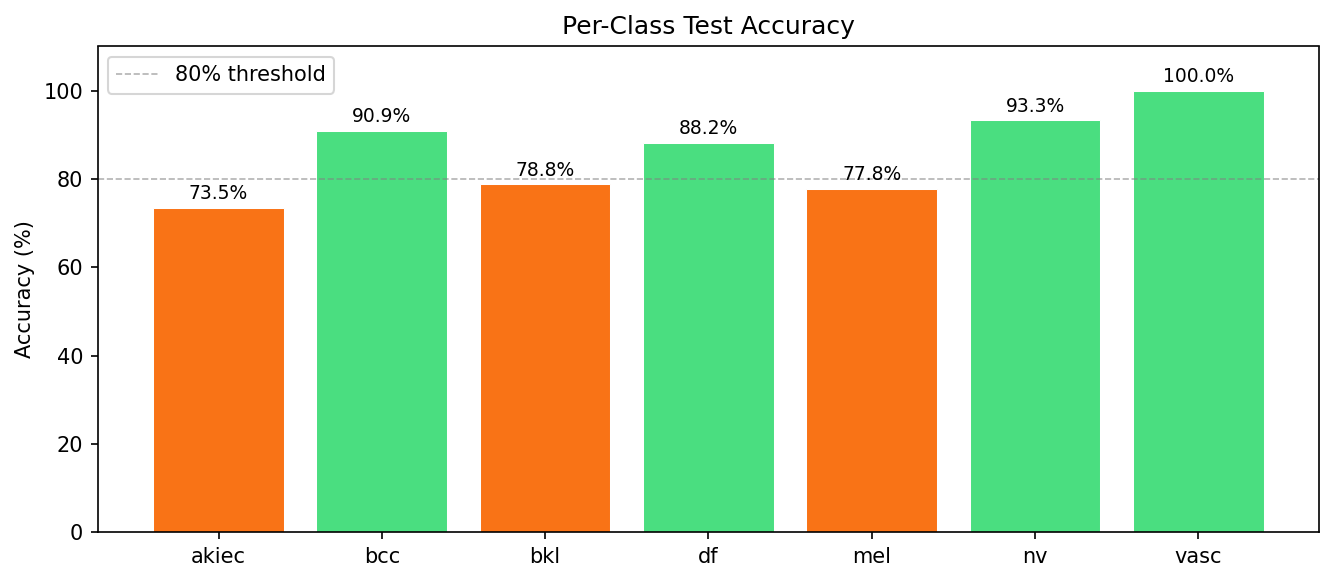


Per-class accuracy:
  akiec :  73.5%  █████████████████████████████
  bcc   :  90.9%  ████████████████████████████████████
  bkl   :  78.8%  ███████████████████████████████
  df    :  88.2%  ███████████████████████████████████
  mel   :  77.8%  ███████████████████████████████
  nv    :  93.3%  █████████████████████████████████████
  vasc  : 100.0%  ████████████████████████████████████████


In [14]:
cm = confusion_matrix(test_labels, test_preds)
per_class_acc = cm.diagonal() / cm.sum(axis=1)

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#ef4444' if a < 0.7 else '#f97316' if a < 0.85 else '#4ade80'
          for a in per_class_acc]
bars = ax.bar(CLASS_NAMES, per_class_acc * 100, color=colors, edgecolor='white', linewidth=0.5)
ax.set_ylim(0, 110)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Per-Class Test Accuracy')
ax.axhline(80, color='gray', linestyle='--', linewidth=0.8, alpha=0.6, label='80% threshold')
ax.legend()
for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f'{acc*100:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
bar_path = CONF_MAT_PATH.replace('confusion_matrix', 'per_class_acc')
plt.savefig(bar_path, dpi=150, bbox_inches='tight')
plt.close()
print(f'Bar chart saved → {bar_path}')

try:
    from IPython.display import Image as IPImage, display
    display(IPImage(bar_path))
except Exception:
    pass

print('\nPer-class accuracy:')
for cls, acc in zip(CLASS_NAMES, per_class_acc):
    bar = '█' * int(acc * 40)
    print(f'  {cls:6s}: {acc*100:5.1f}%  {bar}')

## STEP 16 — Summary

In [18]:
print('╔══════════════════════════════════════════════════════╗')
print('║         SKIN LESION CLASSIFIER v1 — SUMMARY          ║')
print('╠══════════════════════════════════════════════════════╣')
print(f'║  Backbone     : Swin-B (pretrained from SwinUNet v4) ║')
print(f'║  Head         : FPN + GAP + MLP                      ║')
print(f'║  Dataset      : HAM10000 ({len(train_df)+len(val_df)+len(test_df)} images)              ║')
print(f'║  Split        : {len(train_df)} / {len(val_df)} / {len(test_df)} (train/val/test)  ║')
print(f'║  Test Loss    : {test_loss:.4f}                               ║')
print(f'║  Test Accuracy: {test_acc:.4f}  ({test_acc*100:.1f}%)                      ║')
print(f'║  Test Macro F1: {test_f1:.4f}                               ║')
print(f'║  Model saved  → skin_classifier_best.pth             ║')
print(f'║  Report saved → classification_report.txt            ║')
print('╚══════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════╗
║         SKIN LESION CLASSIFIER v1 — SUMMARY          ║
╠══════════════════════════════════════════════════════╣
║  Backbone     : Swin-B (pretrained from SwinUNet v4) ║
║  Head         : FPN + GAP + MLP                      ║
║  Dataset      : HAM10000 (10015 images)              ║
║  Split        : 7010 / 1502 / 1503 (train/val/test)  ║
║  Test Loss    : 1.7051                               ║
║  Test Accuracy: 0.8929  (89.3%)                      ║
║  Test Macro F1: 0.7886                               ║
║  Model saved  → skin_classifier_best.pth             ║
║  Report saved → classification_report.txt            ║
╚══════════════════════════════════════════════════════╝


## STEP 17 — Install XAI Libraries & Setup

In [20]:
!pip install -q grad-cam lime
print('XAI libraries installed.')

XAI libraries installed.


In [21]:
import cv2
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
import os

from pytorch_grad_cam import GradCAM, GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

from lime import lime_image
from skimage.segmentation import mark_boundaries

# ── XAI output directory ──────────────────────────────────────────────────────
XAI_DIR = os.path.join(SAVE_DIR, 'xai_outputs')
os.makedirs(XAI_DIR, exist_ok=True)

# ── Load best model (safe even if you re-run this cell later) ─────────────────
ckpt = torch.load(MODEL_SAVE_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print(f'Model loaded for XAI. Best Val F1: {ckpt["best_val_f1"]:.4f}')

# ── Collect 3 test samples per class (correct predictions preferred) ──────────
SAMPLES_PER_CLASS = 2   # increase to 3 if you want more coverage

# We need raw numpy images (unnormalized) alongside tensors for visualization
inv_normalize = __import__('torchvision').transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

def tensor_to_rgb(tensor):
    """Convert normalized tensor (C,H,W) → float32 RGB numpy (H,W,3) in [0,1]"""
    img = inv_normalize(tensor.cpu()).clamp(0, 1)
    return img.permute(1, 2, 0).numpy().astype(np.float32)

# Gather samples: dict {class_idx: [(tensor, true_label, pred_label), ...]}
xai_samples = {i: [] for i in range(NUM_CLASSES)}
model.eval()

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs_dev = imgs.to(DEVICE)
        logits   = model(imgs_dev)
        preds    = logits.argmax(dim=1).cpu()
        for img, lbl, pred in zip(imgs, labels, preds):
            c = lbl.item()
            if len(xai_samples[c]) < SAMPLES_PER_CLASS:
                xai_samples[c].append((img, c, pred.item()))
        if all(len(v) >= SAMPLES_PER_CLASS for v in xai_samples.values()):
            break

total_samples = sum(len(v) for v in xai_samples.values())
print(f'Collected {total_samples} samples for XAI visualization.')
for i, cls in enumerate(CLASS_NAMES):
    n = len(xai_samples[i])
    print(f'  {cls:6s}: {n} sample(s)')

Model loaded for XAI. Best Val F1: 0.8133
Collected 14 samples for XAI visualization.
  akiec : 2 sample(s)
  bcc   : 2 sample(s)
  bkl   : 2 sample(s)
  df    : 2 sample(s)
  mel   : 2 sample(s)
  nv    : 2 sample(s)
  vasc  : 2 sample(s)


## STEP 18 — Grad-CAM & Grad-CAM++

> Applied on the **last FPN smooth conv layer (P3)** — the deepest, most semantically
> meaningful feature map in your architecture. This tells you exactly which spatial
> region drove the classification decision.
>
> - **Grad-CAM**: gradient × activation → coarse heatmap
> - **Grad-CAM++**: pixel-wise weighted gradients → sharper, handles irregular lesion shapes better

Running Grad-CAM...
  Saved: D:\Multimodal cse8\classification\classifier\xai_outputs\gradcam_akiec.png
  Saved: D:\Multimodal cse8\classification\classifier\xai_outputs\gradcam_bcc.png
  Saved: D:\Multimodal cse8\classification\classifier\xai_outputs\gradcam_bkl.png
  Saved: D:\Multimodal cse8\classification\classifier\xai_outputs\gradcam_df.png
  Saved: D:\Multimodal cse8\classification\classifier\xai_outputs\gradcam_mel.png
  Saved: D:\Multimodal cse8\classification\classifier\xai_outputs\gradcam_nv.png
  Saved: D:\Multimodal cse8\classification\classifier\xai_outputs\gradcam_vasc.png

Running Grad-CAM++...
  Saved: D:\Multimodal cse8\classification\classifier\xai_outputs\gradcampp_akiec.png
  Saved: D:\Multimodal cse8\classification\classifier\xai_outputs\gradcampp_bcc.png
  Saved: D:\Multimodal cse8\classification\classifier\xai_outputs\gradcampp_bkl.png
  Saved: D:\Multimodal cse8\classification\classifier\xai_outputs\gradcampp_df.png
  Saved: D:\Multimodal cse8\classification\cl

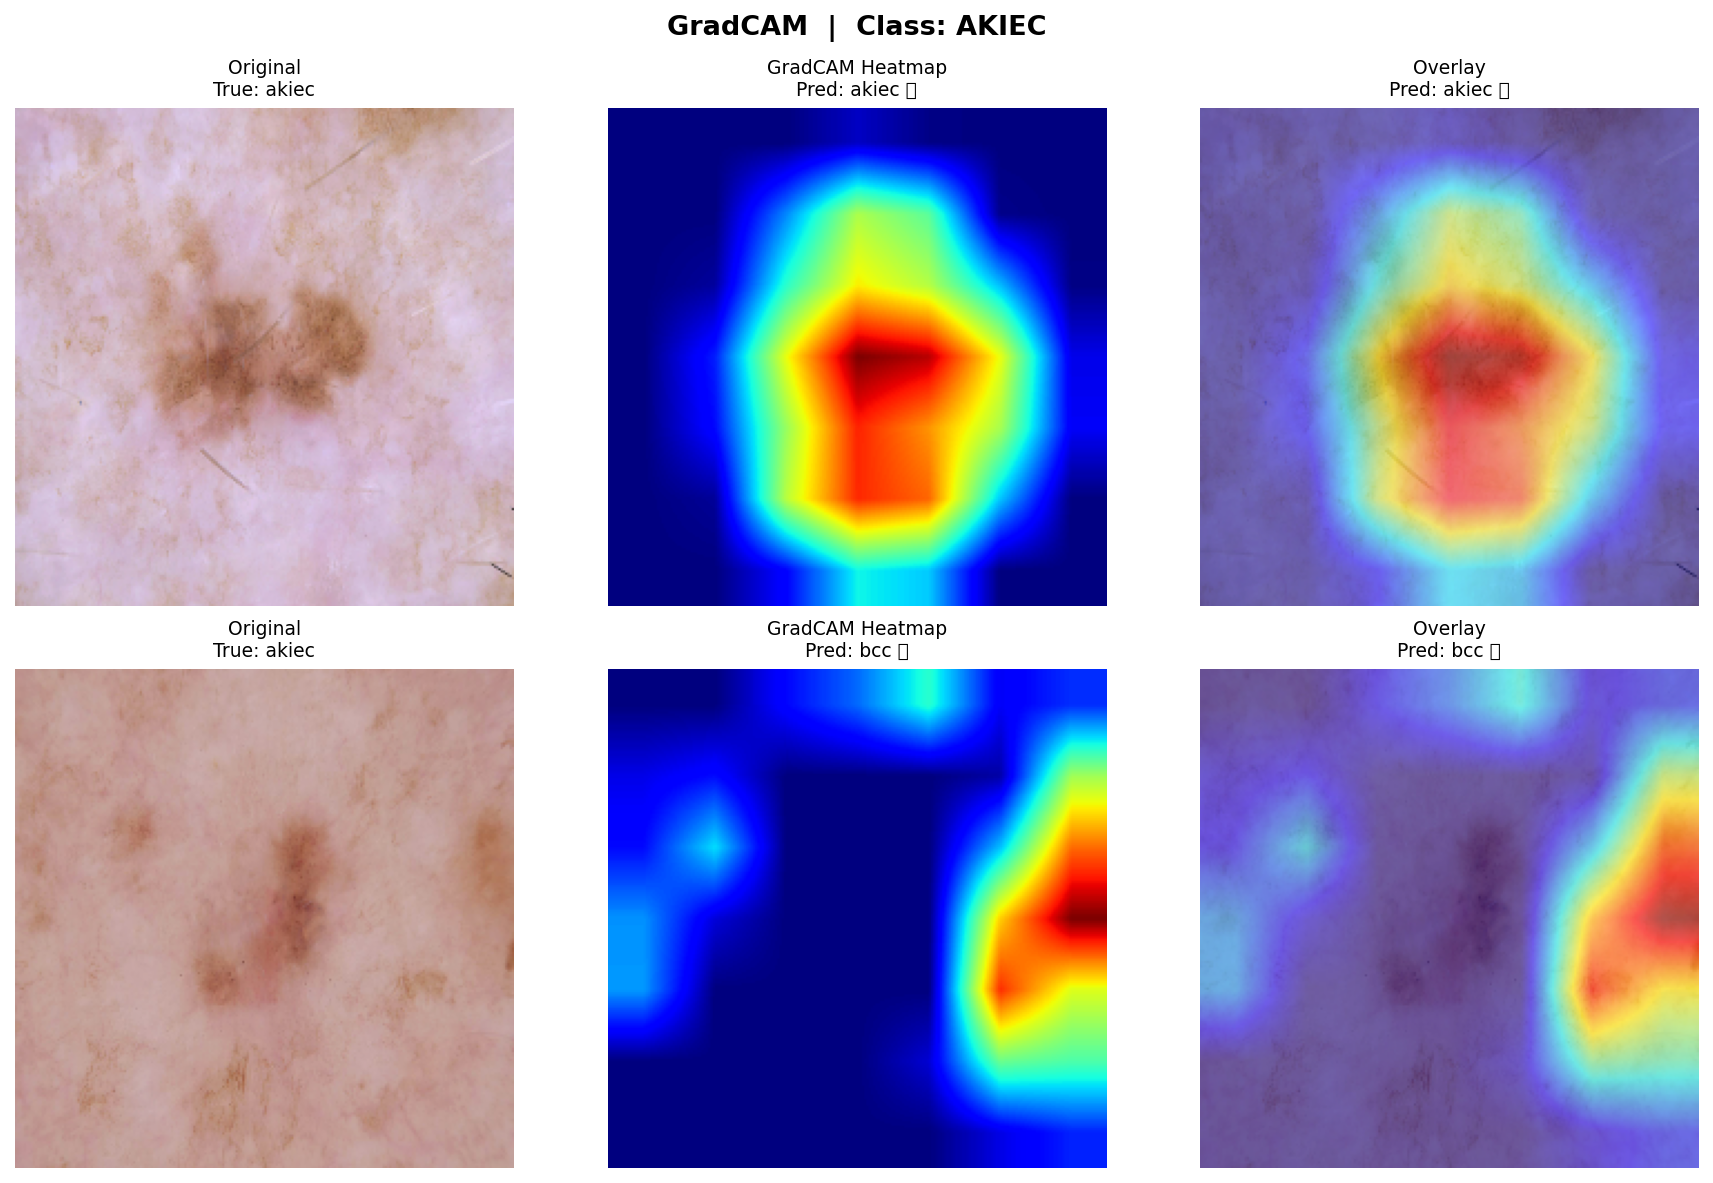

In [22]:
# ── Target layer: last smooth conv in FPN (P3 level = index -1) ───────────────
# This is model.fpn.smooth_convs[-1][0]  (the Conv2d inside the Sequential)
target_layers = [model.fpn.smooth_convs[-1][0]]

# ── Wrapper: grad-cam library needs model.forward() to return logits directly ─
# Our model already does that, so no wrapper needed.

def run_gradcam(sample_dict, method_class, method_name, save_dir):
    """
    Runs Grad-CAM or Grad-CAM++ on all collected samples.
    Saves one figure per class.
    """
    cam_engine = method_class(model=model, target_layers=target_layers)

    for class_idx, samples in sample_dict.items():
        if not samples:
            continue
        cls_name = CLASS_NAMES[class_idx]
        n        = len(samples)
        fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
        if n == 1:
            axes = [axes]  # make iterable

        fig.suptitle(f'{method_name}  |  Class: {cls_name.upper()}', fontsize=13, fontweight='bold')

        for row, (tensor, true_lbl, pred_lbl) in enumerate(samples):
            rgb_img  = tensor_to_rgb(tensor)          # (H,W,3) float32 [0,1]
            input_t  = tensor.unsqueeze(0).to(DEVICE) # (1,C,H,W)

            # Target = predicted class (shows what the model actually focused on)
            targets  = [ClassifierOutputTarget(pred_lbl)]
            grayscale_cam = cam_engine(input_tensor=input_t, targets=targets)[0]

            cam_overlay  = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

            correct      = '✅' if true_lbl == pred_lbl else '❌'
            pred_name    = CLASS_NAMES[pred_lbl]

            axes[row][0].imshow(rgb_img)
            axes[row][0].set_title(f'Original\nTrue: {cls_name}', fontsize=9)
            axes[row][0].axis('off')

            axes[row][1].imshow(grayscale_cam, cmap='jet')
            axes[row][1].set_title(f'{method_name} Heatmap\nPred: {pred_name} {correct}', fontsize=9)
            axes[row][1].axis('off')

            axes[row][2].imshow(cam_overlay)
            axes[row][2].set_title(f'Overlay\nPred: {pred_name} {correct}', fontsize=9)
            axes[row][2].axis('off')

        plt.tight_layout()
        save_path = os.path.join(save_dir, f'{method_name.lower().replace("++","pp")}_{cls_name}.png')
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.close()
        print(f'  Saved: {save_path}')

    cam_engine.__del__() if hasattr(cam_engine, '__del__') else None


print('Running Grad-CAM...')
run_gradcam(xai_samples, GradCAM,       'GradCAM',   XAI_DIR)

print('\nRunning Grad-CAM++...')
run_gradcam(xai_samples, GradCAMPlusPlus, 'GradCAM++', XAI_DIR)

print('\nGrad-CAM & Grad-CAM++ complete.')

# ── Display one example (first class) ─────────────────────────────────────────
try:
    from IPython.display import Image as IPImage, display
    sample_path = os.path.join(XAI_DIR, f'gradcam_{CLASS_NAMES[0]}.png')
    if os.path.exists(sample_path):
        display(IPImage(sample_path))
except Exception:
    pass

## STEP 19 — Occlusion Sensitivity Maps

> Slides a grey patch across the image. Where the **confidence drops most** = the region
> the model depends on most. No gradients involved — purely input-perturbation based.
>
> Most interpretable method for non-ML audiences (doctors, examiners).
> Slower than Grad-CAM but extremely trustworthy.

In [23]:
def occlusion_sensitivity(model, input_tensor, target_class, patch_size=28, stride=14, device=DEVICE):
    """
    Slides a grey (0.5) patch over the image and records confidence drop.
    Returns a sensitivity map of shape (H, W).

    patch_size=28, stride=14 → good balance of resolution vs speed for 224×224
    """
    model.eval()
    C, H, W = input_tensor.shape
    sensitivity_map = np.zeros((H, W), dtype=np.float32)
    count_map       = np.zeros((H, W), dtype=np.float32)

    # Baseline confidence (no occlusion)
    with torch.no_grad():
        base_logits = model(input_tensor.unsqueeze(0).to(device))
        base_prob   = F.softmax(base_logits, dim=1)[0, target_class].item()

    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            occluded = input_tensor.clone()
            occluded[:, y:y+patch_size, x:x+patch_size] = 0.5  # grey patch

            with torch.no_grad():
                logits = model(occluded.unsqueeze(0).to(device))
                prob   = F.softmax(logits, dim=1)[0, target_class].item()

            drop = base_prob - prob   # positive = important region
            sensitivity_map[y:y+patch_size, x:x+patch_size] += drop
            count_map[y:y+patch_size, x:x+patch_size]       += 1

    count_map = np.maximum(count_map, 1)
    sensitivity_map /= count_map

    # Normalise to [0, 1]
    s_min, s_max = sensitivity_map.min(), sensitivity_map.max()
    if s_max > s_min:
        sensitivity_map = (sensitivity_map - s_min) / (s_max - s_min)

    return sensitivity_map


print('Running Occlusion Sensitivity Maps (this takes ~2-4 min for all classes)...')

for class_idx, samples in xai_samples.items():
    if not samples:
        continue
    cls_name = CLASS_NAMES[class_idx]
    n        = len(samples)
    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
    if n == 1:
        axes = [axes]

    fig.suptitle(f'Occlusion Sensitivity  |  Class: {cls_name.upper()}',
                 fontsize=13, fontweight='bold')

    for row, (tensor, true_lbl, pred_lbl) in enumerate(samples):
        rgb_img = tensor_to_rgb(tensor)

        sens_map = occlusion_sensitivity(
            model, tensor, target_class=pred_lbl,
            patch_size=28, stride=14, device=DEVICE
        )

        # Overlay: blend heatmap over original image
        heatmap_colored = cv2.applyColorMap(
            (sens_map * 255).astype(np.uint8), cv2.COLORMAP_JET
        )
        heatmap_rgb = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB) / 255.0
        overlay     = (0.5 * rgb_img + 0.5 * heatmap_rgb).clip(0, 1)

        correct   = '✅' if true_lbl == pred_lbl else '❌'
        pred_name = CLASS_NAMES[pred_lbl]

        axes[row][0].imshow(rgb_img)
        axes[row][0].set_title(f'Original\nTrue: {cls_name}', fontsize=9)
        axes[row][0].axis('off')

        axes[row][1].imshow(sens_map, cmap='hot')
        axes[row][1].set_title(f'Sensitivity Map\nBright = Important', fontsize=9)
        axes[row][1].axis('off')

        axes[row][2].imshow(overlay)
        axes[row][2].set_title(f'Overlay\nPred: {pred_name} {correct}', fontsize=9)
        axes[row][2].axis('off')

    plt.tight_layout()
    save_path = os.path.join(XAI_DIR, f'occlusion_{cls_name}.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f'  {cls_name}: saved → {save_path}')

print('\nOcclusion Sensitivity complete.')

Running Occlusion Sensitivity Maps (this takes ~2-4 min for all classes)...
  akiec: saved → D:\Multimodal cse8\classification\classifier\xai_outputs\occlusion_akiec.png
  bcc: saved → D:\Multimodal cse8\classification\classifier\xai_outputs\occlusion_bcc.png
  bkl: saved → D:\Multimodal cse8\classification\classifier\xai_outputs\occlusion_bkl.png
  df: saved → D:\Multimodal cse8\classification\classifier\xai_outputs\occlusion_df.png
  mel: saved → D:\Multimodal cse8\classification\classifier\xai_outputs\occlusion_mel.png
  nv: saved → D:\Multimodal cse8\classification\classifier\xai_outputs\occlusion_nv.png
  vasc: saved → D:\Multimodal cse8\classification\classifier\xai_outputs\occlusion_vasc.png

Occlusion Sensitivity complete.


## STEP 20 — LIME Explanations

> LIME segments the image into superpixels and perturbs them to find which
> regions, if hidden, change the prediction most.
>
> - **Green regions** = pushed the model TOWARD this class (positive evidence)
> - **Red regions**   = pushed the model AWAY from this class (negative evidence)
>
> Completely model-agnostic — no gradients, no architecture assumptions.

In [25]:
def lime_predict_fn(images_np):
    mean = torch.tensor([0.485, 0.456, 0.406])
    std  = torch.tensor([0.229, 0.224, 0.225])
    batch = []
    for img in images_np:
        t = torch.from_numpy(img).float() / 255.0
        t = (t - mean) / std
        t = t.permute(2, 0, 1)
        batch.append(t)
    batch = torch.stack(batch).to(DEVICE)
    model.eval()
    with torch.no_grad():
        logits = model(batch)
        probs  = F.softmax(logits, dim=1)
    return probs.cpu().numpy()


explainer = lime_image.LimeImageExplainer()

print('Running LIME explanations...')

for class_idx, samples in xai_samples.items():
    if not samples:
        continue
    cls_name  = CLASS_NAMES[class_idx]
    n         = len(samples)
    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
    if n == 1:
        axes = [axes]

    fig.suptitle(f'LIME Explanation  |  Class: {cls_name.upper()}',
                 fontsize=13, fontweight='bold')

    for row, (tensor, true_lbl, pred_lbl) in enumerate(samples):
        rgb_img  = tensor_to_rgb(tensor)
        rgb_uint = (rgb_img * 255).astype(np.uint8)

        explanation = explainer.explain_instance(
            rgb_uint,
            lime_predict_fn,
            top_labels=NUM_CLASSES,    # ← KEY FIX: explain ALL classes, not just top 3
            hide_color=0,
            num_samples=1000,
            random_seed=42
        )

        # ── Safety check: use pred_lbl if available, else fall back ──────────
        available_labels = list(explanation.local_exp.keys())
        label_to_use     = pred_lbl if pred_lbl in available_labels else available_labels[0]
        if label_to_use != pred_lbl:
            print(f'pred_lbl {pred_lbl} not in explanation, '
                  f'falling back to label {label_to_use}')

        # Get mask for predicted class
        temp_img, mask = explanation.get_image_and_mask(
            label_to_use,
            positive_only=False,
            num_features=8,
            hide_rest=False
        )

        # Positive only
        temp_pos, mask_pos = explanation.get_image_and_mask(
            label_to_use,
            positive_only=True,
            num_features=8,
            hide_rest=True
        )

        correct   = '✅' if true_lbl == pred_lbl else '❌'
        pred_name = CLASS_NAMES[pred_lbl]

        axes[row][0].imshow(rgb_img)
        axes[row][0].set_title(f'Original\nTrue: {cls_name}', fontsize=9)
        axes[row][0].axis('off')

        axes[row][1].imshow(mark_boundaries(temp_img / 255.0, mask))
        axes[row][1].set_title(f'LIME: Green=For / Red=Against\nPred: {pred_name} {correct}', fontsize=9)
        axes[row][1].axis('off')

        axes[row][2].imshow(mark_boundaries(temp_pos / 255.0, mask_pos))
        axes[row][2].set_title(f'LIME: Positive Evidence Only\nPred: {pred_name} {correct}', fontsize=9)
        axes[row][2].axis('off')

    plt.tight_layout()
    save_path = os.path.join(XAI_DIR, f'lime_{cls_name}.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f'  {cls_name}: saved → {save_path}')

print('\nLIME complete.')

Running LIME explanations...


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  akiec: saved → D:\Multimodal cse8\classification\classifier\xai_outputs\lime_akiec.png


  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

  nv: saved → D:\Multimodal cse8\classification\classifier\xai_outputs\lime_nv.png


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  vasc: saved → D:\Multimodal cse8\classification\classifier\xai_outputs\lime_vasc.png

LIME complete.


## STEP 21 — XAI Summary Grid

> For each class, shows all 4 XAI methods side by side on the same image.
> One figure per class — ideal for thesis/paper figures.

Generating XAI Summary Grids (1 image per class, all 4 methods)...


  0%|          | 0/1000 [00:00<?, ?it/s]

  akiec: saved → D:\Multimodal cse8\classification\classifier\xai_outputs\xai_summary_akiec.png


  0%|          | 0/1000 [00:00<?, ?it/s]

  bcc: saved → D:\Multimodal cse8\classification\classifier\xai_outputs\xai_summary_bcc.png


...

  mel: saved → D:\Multimodal cse8\classification\classifier\xai_outputs\xai_summary_mel.png


  0%|          | 0/1000 [00:00<?, ?it/s]

  nv: saved → D:\Multimodal cse8\classification\classifier\xai_outputs\xai_summary_nv.png


  0%|          | 0/1000 [00:00<?, ?it/s]

  vasc: saved → D:\Multimodal cse8\classification\classifier\xai_outputs\xai_summary_vasc.png

All XAI Summary Grids saved.


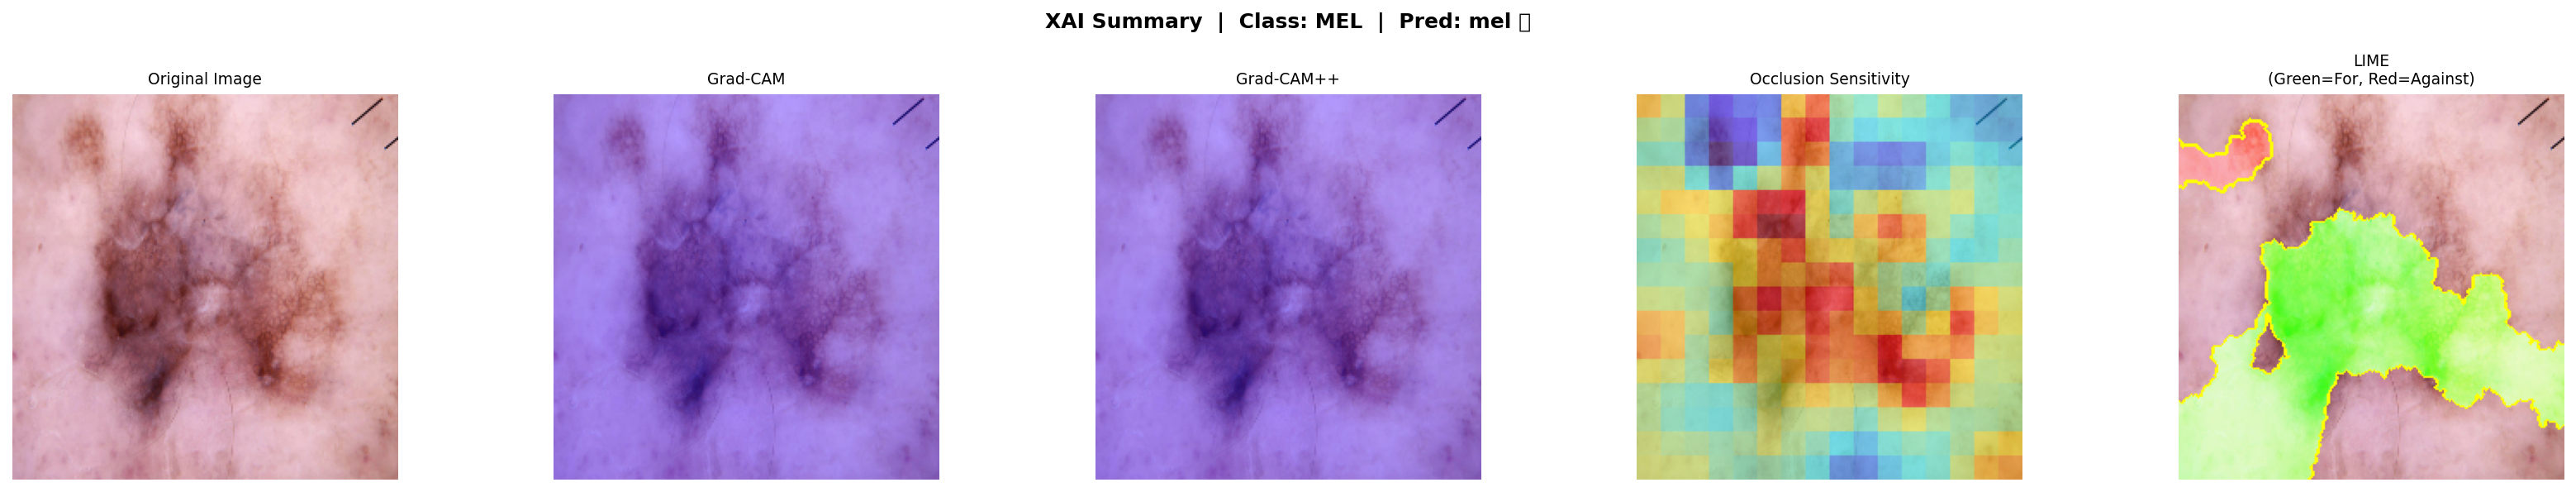

  XAI PIPELINE COMPLETE
  All outputs saved to: D:\Multimodal cse8\classification\classifier\xai_outputs
  Files generated:
    gradcam_akiec.png
    gradcam_bcc.png
    gradcam_bkl.png
    gradcam_df.png
    gradcam_mel.png
    gradcam_nv.png
    gradcam_vasc.png
    gradcampp_akiec.png
    gradcampp_bcc.png
    gradcampp_bkl.png
    gradcampp_df.png
    gradcampp_mel.png
    gradcampp_nv.png
    gradcampp_vasc.png
    lime_akiec.png
    lime_bcc.png
    lime_bkl.png
    lime_df.png
    lime_mel.png
    lime_nv.png
    lime_vasc.png
    occlusion_akiec.png
    occlusion_bcc.png
    occlusion_bkl.png
    occlusion_df.png
    occlusion_mel.png
    occlusion_nv.png
    occlusion_vasc.png
    xai_summary_akiec.png
    xai_summary_bcc.png
    xai_summary_bkl.png
    xai_summary_df.png
    xai_summary_mel.png
    xai_summary_nv.png
    xai_summary_vasc.png


In [27]:
from pytorch_grad_cam import GradCAM, GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

target_layers = [model.fpn.smooth_convs[-1][0]]

print('Generating XAI Summary Grids (1 image per class, all 4 methods)...')

for class_idx, samples in xai_samples.items():
    if not samples:
        continue

    cls_name        = CLASS_NAMES[class_idx]
    tensor, true_lbl, pred_lbl = samples[0]   # use first sample per class
    rgb_img   = tensor_to_rgb(tensor)          # float32 [0,1]
    input_t   = tensor.unsqueeze(0).to(DEVICE)
    rgb_uint  = (rgb_img * 255).astype(np.uint8)
    correct   = '✅' if true_lbl == pred_lbl else '❌'
    pred_name = CLASS_NAMES[pred_lbl]
    targets   = [ClassifierOutputTarget(pred_lbl)]

    # ── 1. Grad-CAM ───────────────────────────────────────────────────────────
    with GradCAM(model=model, target_layers=target_layers) as cam:
        gcam_map     = cam(input_tensor=input_t, targets=targets)[0]
        gcam_overlay = show_cam_on_image(rgb_img, gcam_map, use_rgb=True)

    # ── 2. Grad-CAM++ ─────────────────────────────────────────────────────────
    with GradCAMPlusPlus(model=model, target_layers=target_layers) as cam:
        gcampp_map     = cam(input_tensor=input_t, targets=targets)[0]
        gcampp_overlay = show_cam_on_image(rgb_img, gcampp_map, use_rgb=True)

    # ── 3. Occlusion Sensitivity ──────────────────────────────────────────────
    sens_map = occlusion_sensitivity(
        model, tensor, target_class=pred_lbl,
        patch_size=28, stride=14, device=DEVICE
    )
    heatmap_colored = cv2.applyColorMap(
        (sens_map * 255).astype(np.uint8), cv2.COLORMAP_JET
    )
    occ_overlay = (0.5 * rgb_img +
                   0.5 * cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB) / 255.0
                  ).clip(0, 1)

# ── 4. LIME ───────────────────────────────────────────────────────────────
    lime_exp = explainer.explain_instance(
        rgb_uint, lime_predict_fn,
        top_labels=NUM_CLASSES,    # ← fix: explain all 7 classes
        hide_color=0,
        num_samples=1000, random_seed=42
    )
    # Safety fallback in case pred_lbl still isn't in explanation
    available_labels = list(lime_exp.local_exp.keys())
    label_to_use     = pred_lbl if pred_lbl in available_labels else available_labels[0]

    lime_img, lime_mask = lime_exp.get_image_and_mask(
        label_to_use, positive_only=False,
        num_features=8, hide_rest=False
    )
    lime_overlay = mark_boundaries(lime_img / 255.0, lime_mask)

    # ── Plot 1×5 grid ─────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 5, figsize=(22, 4))
    fig.suptitle(
        f'XAI Summary  |  Class: {cls_name.upper()}  '
        f'|  Pred: {pred_name} {correct}',
        fontsize=12, fontweight='bold'
    )

    panels = [
        (rgb_img,         'Original Image',      None),
        (gcam_overlay,    'Grad-CAM',             None),
        (gcampp_overlay,  'Grad-CAM++',           None),
        (occ_overlay,     'Occlusion Sensitivity',None),
        (lime_overlay,    'LIME\n(Green=For, Red=Against)', None),
    ]
    for ax, (img, title, cmap) in zip(axes, panels):
        ax.imshow(img, cmap=cmap)
        ax.set_title(title, fontsize=9)
        ax.axis('off')

    plt.tight_layout()
    save_path = os.path.join(XAI_DIR, f'xai_summary_{cls_name}.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f'  {cls_name}: saved → {save_path}')

print('\nAll XAI Summary Grids saved.')

# Display one example
try:
    from IPython.display import Image as IPImage, display
    ex_path = os.path.join(XAI_DIR, f'xai_summary_{CLASS_NAMES[4]}.png')  # mel
    if os.path.exists(ex_path):
        display(IPImage(ex_path))
except Exception:
    pass

print('  XAI PIPELINE COMPLETE')
print(f'  All outputs saved to: {XAI_DIR}')
print('  Files generated:')
for f in sorted(os.listdir(XAI_DIR)):
    print(f'    {f}')